In [111]:
#https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/section-3-structured-data-projects/end-to-end-heart-disease-classification.ipynb
#https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/section-3-structured-data-projects/end-to-end-heart-disease-classification-video.ipynb
#https://github.com/mrdbourke/zero-to-mastery-ml/tree/master/section-3-structured-data-projects

In [1]:
#what we'll do:
#Exploratory data analysis (EDA)	The process of going through a dataset and discovering more about it.
#Model training	Create model(s) to learn to predict a target variable based on other variables.
#Model evaluation	Evaluating a model's predictions using problem-specific evaluation metrics.
#Model comparison	Comparing several different models to find the best one.
#Model hyperparameter tuning	Once we've found a good model, can we tweak its hyperparameters to improve it?
#Feature importance	Since we're predicting the presence of heart disease, are there some features/characteristics that are more important for prediction?
#Cross-validation	If we do build a good model, can we be sure it will work on unseen data?
#Reporting what we've found	If we had to present our work, what would we show someone?

In [2]:
#The original database contains 76 attributes, but here only 14 attributes will be used. Attributes (also called features) are the variables what we'll use to predict our target variable.
#Attributes / features are also referred to as Independent Variables and a target variable can be referred to as a Dependent Variable.

In [3]:
#at the beginning, for have a direction to reach, you can say to yourself:
#"If we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept, we'll pursure this project".

In [4]:
#################1.Valuate the Data
#from the db HeartDisease (76 features), we build the Data Dictionary, and get only 14 features: 
#Feature	  Description	     Example Values
#age	Age in years	29, 45, 60
#sex	1 = male; 0 = female	0, 1
#cp	Chest pain type	0: Typical angina (chest pain), 1: Atypical angina (chest pain not related to heart), 2: Non-anginal pain (typically esophageal spasms (non heart related), 3: Asymptomatic (chest pain not showing signs of disease)
#trestbps	Resting blood pressure (in mm Hg on admission to the hospital)	120, 140, 150
#chol	Serum cholesterol in mg/dl	180, 220, 250
#fbs	Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)	0, 1
#restecg	Resting electrocardiographic results	0: Nothing to note, 1: ST-T Wave abnormality, 2: Left ventricular hypertrophy
#thalach	Maximum heart rate achieved	160, 180, 190
#exang	Exercise induced angina (1 = yes; 0 = no)	0, 1
#oldpeak	ST depression (heart potentially not getting enough oxygen) induced by exercise relative to rest	0.5, 1.0, 2.0
#slope	The slope of the peak exercise ST segment	0: Upsloping, 1: Flatsloping, 2: Downsloping
#ca	Number of major vessels (0-3) colored by fluoroscopy	0, 1, 2, 3
#thal	Thalium stress result	1: Normal, 3: Normal, 6: Fixed defect, 7: Reversible defect
#target	Have disease or not (1 = yes; 0 = no)	0, 1

#It's aalways a good idea to save these to a Python dictionary or in an external file, so we can look at them later without coming back here.

In [112]:
#################2. Preparing Tools
%matplotlib inline
import matplotlib.pyplot as plt  #solo il modulo x i graphs
import matplotlib   #lib completa
import numpy as np
import pandas as pd
import seaborn as sns     # seaborn gets shortened to sns, TK - can seaborn be removed for matplotlib (simpler)?

## Models
import sklearn 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
# from sklearn.metrics import plot_roc_curve # note: this was changed in Scikit-Learn 1.2+ to be "RocCurveDisplay" (see below)
from sklearn.metrics import RocCurveDisplay # new in Scikit-Learn 1.2+

# Print last updated
import datetime
print(f"Notebook last updated: {datetime.datetime.now()}\n")

# Print versions of libraries we're using (as long as yours are equal or greater than these, your code should work)
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

Notebook last updated: 2026-04-17 12:40:01.134320

NumPy version: 2.4.3
pandas version: 3.0.2
matplotlib version: 3.10.8
Scikit-Learn version: 1.8.0


In [6]:
#################3. Loading Data
df = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv")
# df = pd.read_csv("../data/heart-disease.csv") # Read from local directory, 'DataFrame' shortened to 'df'
df.shape # (rows, columns)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
#################4. Exploratory Data Analysis (EDA): semplicemente esplora per conoscere a 360° il tuo dataset, prima di iniziare la modellazione. 

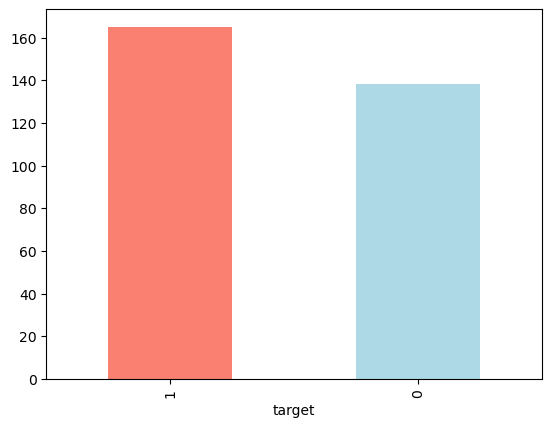

In [8]:
# Let's see how many positive (1) and negative (0) samples we have in our DataFrame
df.target.value_counts()
#vedendo i risultait, since these two values are close to even, our target column can be considered BALANCED.
#An UNBALANCED target column, meaning some classes have far more samples, can be harder to model than a balanced set.

# Normalized value counts
df.target.value_counts(normalize=True)  #semplicemente vediamo in percentages

# Plot the value counts with a bar graph
df.target.value_counts().plot(kind="bar", color=["salmon", "lightblue"]);  #visualizziamo su graph


In [9]:
#DF insights
df.info()  #it shows a quick insight into the number of missing values you have and what type of data you're working with.
#in our case, there are no missing values and all of our columns are numerical in nature.

df.describe()  #describe() shows a range of different metrics about your numerical columns such as mean, max and standard deviation.

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
#Comparing one feature to another

#Let's Compare our target column with the sex column feauture

df.sex.value_counts()  #returns count of 1=male and 0=female.

sex
1    207
0     96
Name: count, dtype: int64

In [11]:
# Compare target column with sex column. remember that for out target column 1=heart disease present 0=no heart disease.
pd.crosstab(index=df.target, columns=df.sex)

#da quello che vidiamo, 
#the woman have ~72% (72/96 women in our dataset are positive for heart disease) chance she has heart disease.
#the men ~45% (93/207 men in our dataset are positive for heart disease) chance he has heart disease.
#quindi per una Person, ha una chance ~62.5% che ha un heart disease, questa puo essere la nostra semplice Baseline!

sex,0,1
target,,
0,24,114
1,72,93


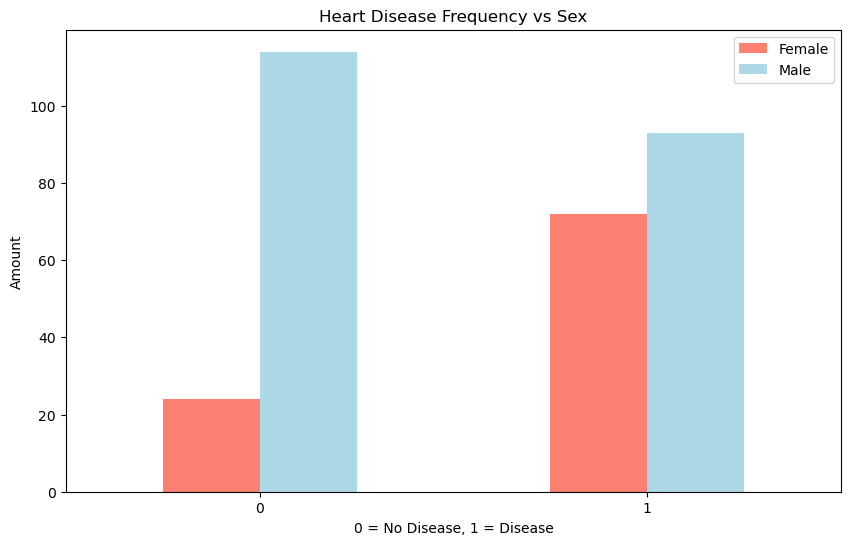

In [12]:
# Create a plot
pd.crosstab(df.target, df.sex).plot(kind="bar", figsize=(10,6), color=["salmon", "lightblue"])

# Add some attributes to it
plt.title("Heart Disease Frequency vs Sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0); # keep the labels on the x-axis vertical

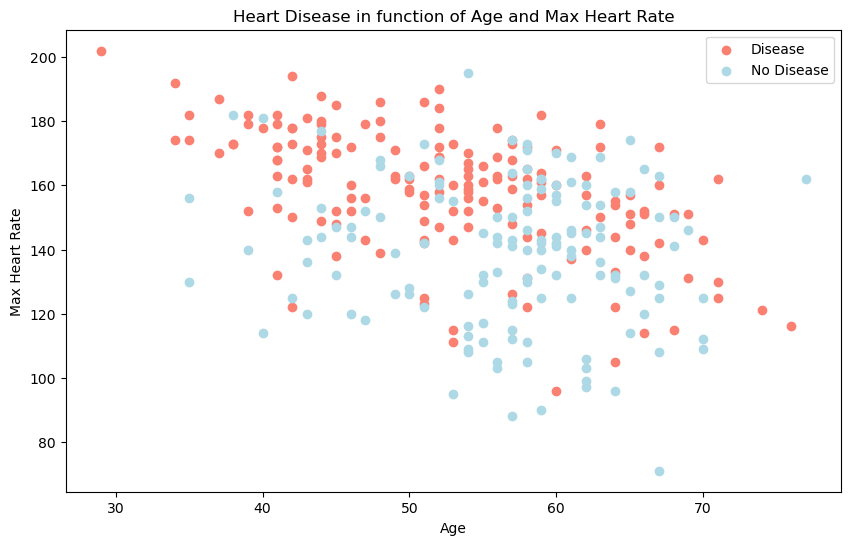

In [13]:
#Comparing age and maximum heart rate

#combining a couple of independent variables (age and thalach (maximum heart rate)) and then comparing them to our target variable heart disease.

# Create another figure
plt.figure(figsize=(10,6))

# Start with positve examples
plt.scatter(df.age[df.target==1], 
            df.thalach[df.target==1], 
            c="salmon") # define it as a scatter figure

# Now for negative examples, we want them on the same plot, so we call plt again
plt.scatter(df.age[df.target==0], 
            df.thalach[df.target==0], 
            c="lightblue") # axis always come as (x, y)

# Add some helpful info
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.legend(["Disease", "No Disease"])
plt.ylabel("Max Heart Rate");

#okey, we notice that it seems the younger someone is, the higher their max heart rate (dots are higher on the left of the graph) and 
#it seems there may be more heart disease in the younger population too (more orange dots).

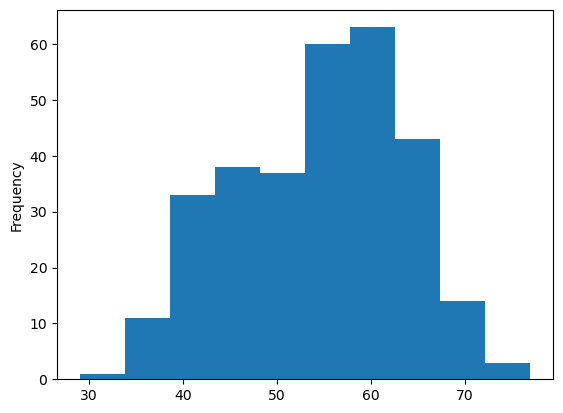

In [14]:
#Let's check the age distribution

# Histograms are a great way to check the distribution of a variable
df.age.plot.hist();

In [15]:
#Comparing heart disease frequency and chest pain type

pd.crosstab(index=df.cp, columns=df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


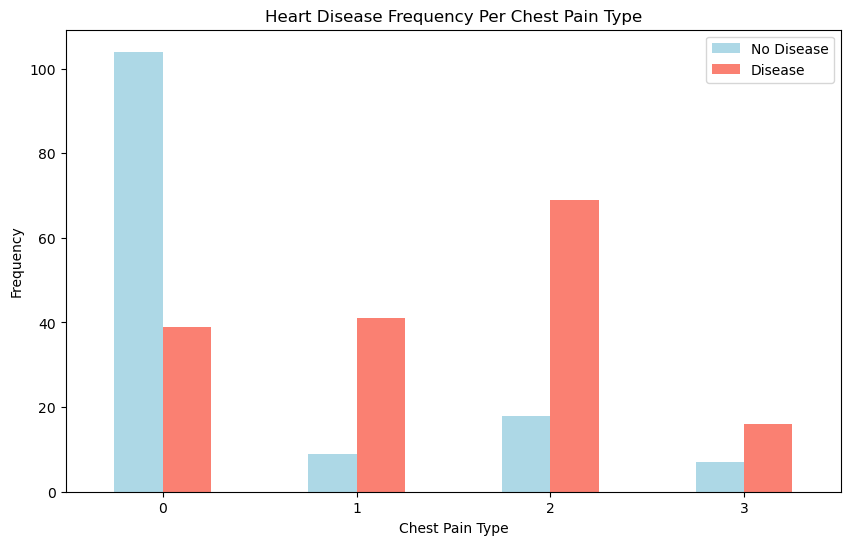

In [16]:
# Create a new crosstab and base plot
pd.crosstab(df.cp, df.target).plot(kind="bar", 
                                   figsize=(10,6), 
                                   color=["lightblue", "salmon"])

# Add attributes to the plot to make it more readable
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation = 0);

#It's interesting that atypical angina (value 1, check ur Data Dictionary) states it's not related to the heart but seems to have a higher ratio of participants with heart disease than not.
#but wait...What does atypical agina even mean?  if your data dictionary doesn't supply you enough information, you may want to do further research on your values asking to subject matter experts (e.g. cardiologist)

In [17]:
#Correlation between independent variables 

#we'll compare all of the independent variables in one hit, 
#this may give an idea of which independent variables may or may NOT have an impact on our target variable.

# Find the correlation between our independent variables
corr_matrix = df.corr()   #.corr() creates a correlation matrix
corr_matrix 

#A higher positive value means a potential positive correlation (increase) and a higher negative value means a potential negative correlation (decrease).

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


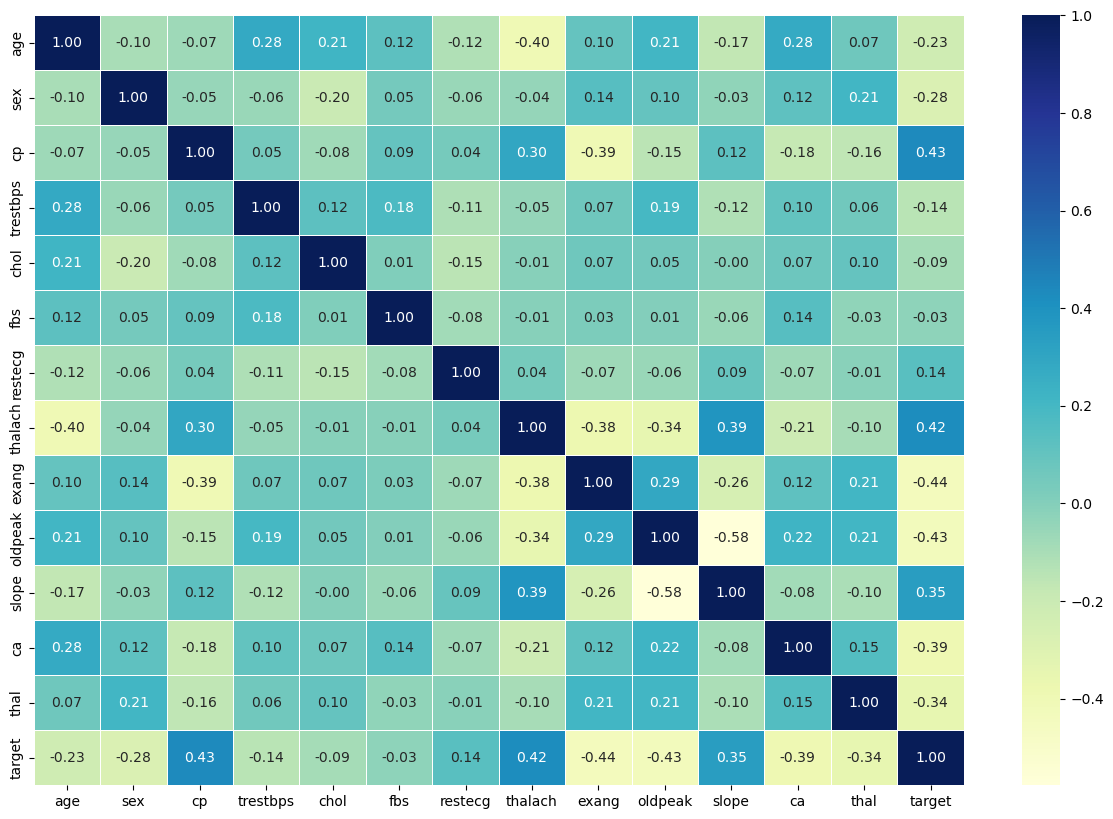

In [18]:
#visualize
corr_matrix = df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            linewidths=0.5, 
            fmt= ".2f", 
            cmap="YlGnBu");

#A higher positive value means a potential positive correlation (increase) and a higher negative value means a potential negative correlation (decrease).

In [19]:
#okey, per ora va bene cosi x EDA.
#Aside from our baseline estimate using sex, the rest of the data seems to require a bit more exploration before we draw any conclusions.
#In relaity uite often, you'll want to find also:
#Distributions - What's the spread of the data? We can do this with pd.DataFrame.hist(column="target_column").
#Missing values - Is our data missing anything? Why might this be the case and will this affect us going forward? We can do this with pd.DataFrame.info() or pd.isnull().
#Outliers - Are there any samples that lay quite far outside the rest of our data's distributions? How might these affect the data going forward?

In [20]:
#################5. Modeling

In [21]:
# Everything except target variable
X = df.drop(labels="target", axis=1)

# Target variable
y = df.target.to_numpy()

In [22]:
# Targets (in the form of a NumPy array)
y, type(y)

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [23]:
# Random seed for reproducibility (since train_test_split is random by default, setting the seed will create reproducible splits)
np.random.seed(42)

# Split into train & test set
X_train, X_test, y_train, y_test = train_test_split(X, # independent variables 
                                                    y, # dependent variable
                                                    test_size = 0.2) # percentage of data to use for test set

In [24]:
y_train, len(y_train)

(array([1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
        1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
        0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
        1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
        1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
        1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
        0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
        1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1]),
 242)

In [25]:
y_test, len(y_test)

(array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
        0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0]),
 61)

In [26]:
#Choosing a Model
#We'll start by trying the following models(check always MAP sklearn x models) and comparing their results.
#Logistic Regression - sklearn.linear_model.LogisticRegression()
#K-Nearest Neighbors - sklearn.neighbors.KNeighboursClassifier()
#RandomForest - sklearn.ensemble.RandomForestClassifier()

In [28]:
#model Logistic Regression when you read the Scikit-Learn documentation find ou that is a model x Classification!
#for sklearn.svm.LinearSVC, let's pretend we've tried it (you can try it for yourself if you like), and it doesn't work, so we're following other options in the MAP.

In [29]:
# Put models in a dictionary
models = {"KNN": KNeighborsClassifier(),
          "Logistic Regression": LogisticRegression(max_iter=100), # Note: if you see a warning about "convergence not reached", you can increase `max_iter` until convergence is reached
          "Random Forest": RandomForestClassifier()}

# Create function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models : a dict of different Scikit-Learn machine learning models
    X_train : training data
    X_test : testing data
    y_train : labels assosciated with training data
    y_test : labels assosciated with test data
    """
    # Random seed for reproducible results
    np.random.seed(42)
    # Make a list to keep model scores
    model_scores = {}
    # Loop through models
    for name, model in models.items():
        # Fit the model to the data
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to model_scores
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [31]:
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)
model_scores

#ok, It looks like each of our models was able to fit our data without any errors.

D:\Miniconda\envs\ml_scikit-learn_1_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.6885245901639344,
 'Logistic Regression': 0.8852459016393442,
 'Random Forest': 0.8360655737704918}

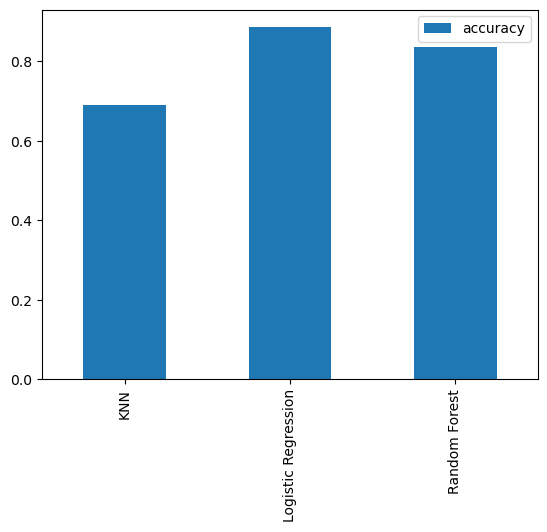

In [33]:
# Comparing the results of several models
model_compare = pd.DataFrame(model_scores, index=['accuracy'])
model_compare.T.plot.bar();

#perfect, now you find out the best model for our problem! is Logisitic Regression model!

In [34]:
#################6. Hyperparameter tuning and cross-validation

In [35]:
#Tune KNeighborsClassifier (K-Nearest Neighbors or KNN) by hand

# Create a list of train scores
train_scores = []

# Create a list of test scores
test_scores = []

# Create a list of different values for n_neighbors
neighbors = range(1, 21) # 1 to 20

# Setup algorithm
knn = KNeighborsClassifier()

# Loop through different neighbors values
for i in neighbors:
    knn.set_params(n_neighbors = i) # set neighbors value
    
    # Fit the algorithm
    knn.fit(X_train, y_train)
    
    # Update the training scores
    train_scores.append(knn.score(X_train, y_train))
    
    # Update the test scores
    test_scores.append(knn.score(X_test, y_test))

In [36]:
#Now let's look at KNN's train scores.
train_scores

[1.0,
 0.8099173553719008,
 0.7727272727272727,
 0.743801652892562,
 0.7603305785123967,
 0.7520661157024794,
 0.743801652892562,
 0.7231404958677686,
 0.71900826446281,
 0.6942148760330579,
 0.7272727272727273,
 0.6983471074380165,
 0.6900826446280992,
 0.6942148760330579,
 0.6859504132231405,
 0.6735537190082644,
 0.6859504132231405,
 0.6652892561983471,
 0.6818181818181818,
 0.6694214876033058]

Maximum KNN score on the test data: 75.41%


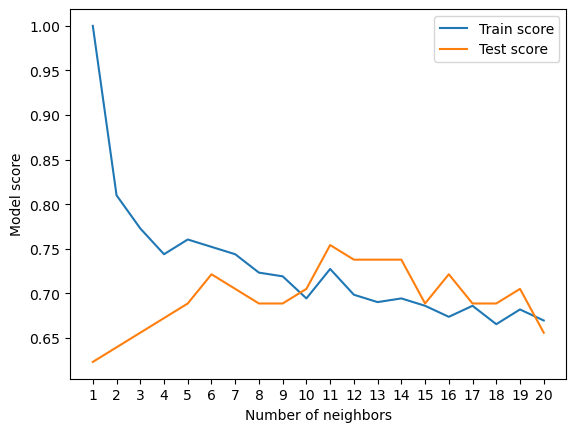

In [39]:
#visualize!
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()

print(f"Maximum KNN score on the test data: {max(test_scores)*100:.2f}%")

#We've tuned KNN by hand
#Looking at the graph, n_neighbors = 11 seems best.
#Even knowing this, the KNN's model performance didn't get near what LogisticRegression or the RandomForestClassifier did!!
#Because of this, we'll discard KNN and focus on the other two(LogisticsRegression and RandomForestClassifier).

In [61]:
#now before we tuning the models using RandomizedSearchCV, and after we tuning the models using GridSearchCV:
#-RandomizedSearchCV: searches over a grid of hyperparameters performing n_iter combinations (e.g. will explore random combinations of the hyperparameters for a defined number of iterations).
#-GridSearchCV: will test every single possible combination of hyperparameters in the grid (this is a thorough test but can take quite a long time).

In [62]:
#Tuning models with RandomizedSearchCV (applied on model LogisticsRegression and RandomForestClassifier)

In [41]:
#Let's create a hyperparameter grid (a dictionary of different hyperparameters) for each model.
#!Be careful creating a hyperparameter dictionary for tuning as if there are typos in the keys of the dictionary, you will find that your code hyperparameter tuning code will produce errors.

# Different LogisticRegression hyperparameters
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

# Different RandomForestClassifier hyperparameters
rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2)}

In [44]:
#Tune the LogisticRegression model w RandomizedSearchCV
#We'll pass it the different hyperparameters from log_reg_grid as well as set n_iter=20. This means, RandomizedSearchCV will try 20 different combinations of hyperparameters from log_reg_grid and save the best ones.

%%time

# Setup random seed
np.random.seed(42)

# Setup random hyperparameter search for LogisticRegression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)

# Fit random hyperparameter search model
rs_log_reg.fit(X_train, y_train);

UsageError: Line magic function `%%time` not found.


In [45]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [47]:
rs_log_reg.score(X_test, y_test)

#nice! seems on par with the result we got before without any hyperparameter tuning. 
#Many of the algorithms in Scikit-Learn have pretty good default hyperparameter values so don't be surprised if they perform pretty good on your data straight out of the box.
#But don't take this as being true all the time!

0.8852459016393442

In [52]:
#Tune the RandomForestClassifier model w RandomizedSearchCV 
%%time 

# Setup random seed
np.random.seed(42)

# Setup random hyperparameter search for RandomForestClassifier
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=True)

# Fit random hyperparameter search model
rs_rf.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [53]:
# Find the best parameters
rs_rf.best_params_

{'n_estimators': np.int64(210),
 'min_samples_split': np.int64(4),
 'min_samples_leaf': np.int64(19),
 'max_depth': 3}

In [54]:
# Evaluate the randomized search random forest model
rs_rf.score(X_test, y_test)

0.8688524590163934

In [55]:
#ok, Tuning the hyperparameters for each model saw a slight performance boost in both the RandomForestClassifier and LogisticRegression.

In [63]:
#Tuning models with GridSearchCV!

In [64]:
%%time

# Different LogisticRegression hyperparameters
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

# Setup grid hyperparameter search for LogisticRegression
gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid=log_reg_grid,
                          cv=5,
                          verbose=True)

# Fit grid hyperparameter search model
gs_log_reg.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits
CPU times: total: 359 ms
Wall time: 511 ms


In [65]:
# Check the best parameters
gs_log_reg.best_params_

{'C': np.float64(0.23357214690901212), 'solver': 'liblinear'}

In [67]:
# Evaluate the model
gs_log_reg.score(X_test, y_test)

#here we get the same results as before since our grid only has a maximum of 20 different hyperparameter combinations.

0.8852459016393442

In [68]:
#################7. Evaluating a classification model, beyond accuracy

In [70]:
#Now we've got a tuned model, let's get some of the metrics we discussed before: 
    #ROC curve and AUC score, Confusion matrix, Classification report, Precision, Recall, F1-score 
#Scikit-Learn has these all built-in.

In [73]:
# Make preidctions on test data
y_preds = gs_log_reg.predict(X_test)
y_preds

#good, they look like our original test data labels, except different where the model has predicred wrong.

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [74]:
y_test   #see original test data labels

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

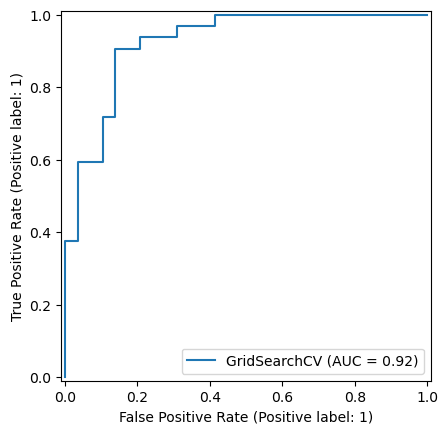

In [76]:
# ROC Curve and AUC Scores

# Before Scikit-Learn 1.2.0 (will error with versions 1.2+)
# from sklearn.metrics import plot_roc_curve 
# plot_roc_curve(gs_log_reg, X_test, y_test);

# Scikit-Learn 1.2.0 or later
from sklearn.metrics import RocCurveDisplay 

# from_estimator() = use a model to plot ROC curve on data
RocCurveDisplay.from_estimator(estimator=gs_log_reg, 
                               X=X_test, 
                               y=y_test); 

#This is great, our model does far better than guessing which would be a line going from the bottom left corner to the top right corner, AUC = 0.5.
#But a perfect model would achieve an AUC score of 1.0, so there's still room for improvement.

In [77]:
#Creating a confusion matrix
#A confusion matrix is a visual way to show where your model made the right predictions and where it made the wrong predictions (or in other words, got confused).

# Display confusion matrix
print(confusion_matrix(y_test, y_preds))

[[25  4]
 [ 3 29]]


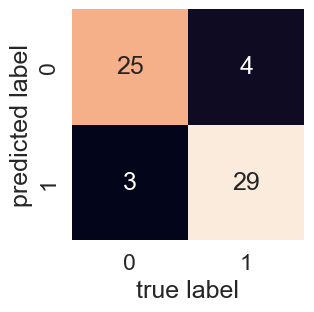

In [79]:
#visual

# Import Seaborn
import seaborn as sns
sns.set(font_scale=1.5) # Increase font size

def plot_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix using Seaborn's heatmap().
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True, # Annotate the boxes
                     cbar=False)
    plt.xlabel("true label")
    plt.ylabel("predicted label")
    
plot_conf_mat(y_test, y_preds)

#In essence, there are 4 occasaions where the model predicted 0 when it should've been 1 (false negative) and 3 occasions 
#where the model predicted 1 instead of 0 (false positive).
#As further evaluation, look into these samples and see why this may be the case.

In [81]:
# Classification report
#A classification report is a collection of different metrics and other details.

In [82]:
# Show classification report
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



In [83]:
# Check best hyperparameters
gs_log_reg.best_params_

{'C': np.float64(0.23357214690901212), 'solver': 'liblinear'}

In [85]:
# Import cross_val_score
from sklearn.model_selection import cross_val_score

# Instantiate best model with best hyperparameters (found with GridSearchCV)
clf = LogisticRegression(C=0.23357214690901212,
                         solver="liblinear")

#Now we've got an instantiated classifier, let's find some cross-validated metrics.

In [87]:
%%time

# Cross-validated accuracy score
cv_acc = cross_val_score(clf,
                         X,
                         y,
                         cv=5, # 5-fold cross-validation, this is the default
                         scoring="accuracy") # accuracy as scoring
cv_acc  #we get the 5 values
cv_acc = np.mean(cv_acc)  #get the mean
cv_acc

CPU times: total: 46.9 ms
Wall time: 44.3 ms


np.float64(0.8479781420765027)

In [ ]:
#Now we'll do the same for other classification metrics: scoring="precision", scoring="recall", scoring="recall"

In [91]:
# Cross-validated precision score
cv_precision = np.mean(cross_val_score(clf,
                                       X,
                                       y,
                                       cv=5, # 5-fold cross-validation
                                       scoring="precision")) # precision as scoring

# Cross-validated recall score
cv_recall = np.mean(cross_val_score(clf,
                                    X,
                                    y,
                                    cv=5, # 5-fold cross-validation
                                    scoring="recall")) # recall as scoring

# Cross-validated F1 score
cv_f1 = np.mean(cross_val_score(clf,
                                X,
                                y,
                                cv=5, # 5-fold cross-validation
                                scoring="f1")) # f1 as scoring

cv_precision
cv_recall
cv_f1
print(f"Precision: {cv_precision} | Recall: {cv_recall} | F1: {cv_f1}")

Precision: 0.8215873015873015 | Recall: 0.9272727272727274 | F1: 0.8705403543192143


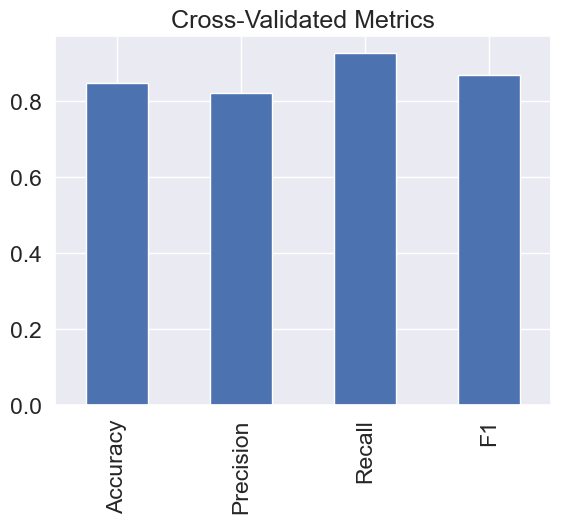

In [92]:
#visualize all 4 them!

# Visualizing cross-validated metrics
cv_metrics = pd.DataFrame({"Accuracy": cv_acc,
                            "Precision": cv_precision,
                            "Recall": cv_recall,
                            "F1": cv_f1},
                          index=[0])
cv_metrics.T.plot.bar(title="Cross-Validated Metrics", legend=False);

In [94]:
#################8. Feature importance
#find out "Which features contribute most to the outcomes of the model?"
#Because how each model finds patterns in data is slightly different, how a model judges how important those patterns are is different as well.
#This means for each model, there's a slightly different way of finding which features were most important and in turn, the FEATURE IMPORTANCE of one model won't necessarily reflect the feature importance of another.

In [95]:
#Since we're using LogisticRegression, we'll look at one way we can calculate feature importance for it.
#we'll use the coef_ attribute, the coef_ attribute is the coefficient of the features in the decision function.
#We can ONLY access the coef_ attribute after we've fit an instance of LogisticRegression

In [97]:
# Fit an instance of LogisticRegression (taken from above)
clf.fit(X_train, y_train);

# Check coef_
clf.coef_
#Looking at this it might not make much sense.
#But these values are how much each feature contributes to how a model makes a decision on whether patterns in a sample of patients health data leans more towards having heart disease or not.

#now we combine coef_ results w columns (features) of our dataframe, per dare un chiaro senso ai risultati di coef_
# Match features to columns
features_dict = dict(zip(df.columns, list(clf.coef_[0])))
features_dict

{'age': np.float64(0.003699220174010677),
 'sex': np.float64(-0.9042408884092753),
 'cp': np.float64(0.6747282647502363),
 'trestbps': np.float64(-0.01161340200892909),
 'chol': np.float64(-0.001703644248287853),
 'fbs': np.float64(0.04787688328393058),
 'restecg': np.float64(0.334901950899703),
 'thalach': np.float64(0.024729383535366262),
 'exang': np.float64(-0.6312040458728754),
 'oldpeak': np.float64(-0.5759093903593269),
 'slope': np.float64(0.470951339901914),
 'ca': np.float64(-0.6516534866417174),
 'thal': np.float64(-0.6998420566308521)}

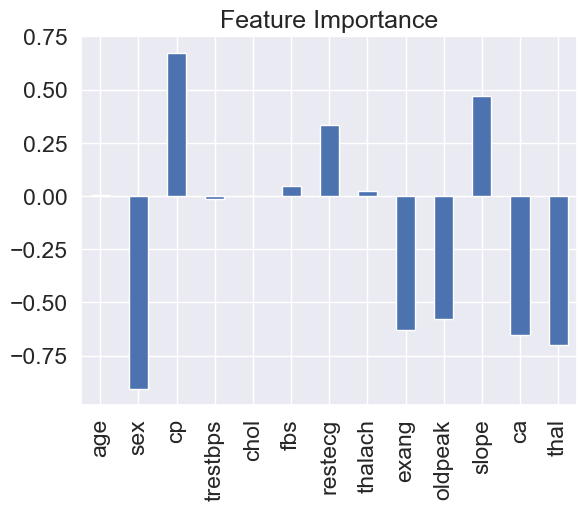

In [100]:
#visualize it!

# Visualize feature importance
features_df = pd.DataFrame(features_dict, index=[0])
features_df.T.plot.bar(title="Feature Importance", legend=False);

#we find out
#The larger the value (bigger bar), the more the feature contributes to the models decision.
#If the value is negative, it means there's a negative correlation. And vice versa for positive values.
#e.g. the sex attribute has a negative value of -0.904, which means as the value for sex increases, the target value decreases.

In [106]:
#comparing Sex column w Target column
pd.crosstab(df["sex"], df["target"])
#remember 0=fermale 1=male, and 0=noDisease 1=disease
#the model has found a pattern which reflects the data. Looking at these figures and this specific dataset, it seems if the patient is female, they're more likely to have heart disease.

#comparing slope (positive coefficient) column w Target column
pd.crosstab(df["slope"], df["target"])
#remember 0=Upsloping: better heart rate with excercise (uncommon), 1=Flatsloping: minimal change (typical healthy heart), 2=Downslopins: signs of unhealthy heart
#This positive correlation means our model is picking up the pattern that as slope increases, so does the target value.
#this is a pattern foud out by the model! x know why you should talk with a Subject Matter Expert (e.g.a doctor)!

#talking with an expert, can help you:
#If some of the correlations and feature importances are confusing, a subject matter expert may be able to shed some light on the situation and help you figure out more.
#If some features offer far more value than others, this may change how you collect data for different problems. 
#🔥🔥if some features are offering far more value than others, you could reduce the number of features your model tries to find patterns in as well as improve the ones which offer the most. This could potentially lead to saving on computation, by having a model find patterns across less features, whilst still achieving the same performance levels.

target,0,1
slope,,
0,12,9
1,91,49
2,35,107


In [110]:
#################9. Experimentation
#So by this stage, after trying a few different things, we'd ask ourselves did we meet the evaluation metric?
#remeber our baseline definited at the start: "If we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept, we'll pursue this project."
#now The highest accuracy our model achieved was below 90%.
#so we SHOULD AND MUST CONTINUE THE EXPERIMENTS, always trying something different and improve our accuracy for the model!!
#🔥🔥REMBER, YOUR BIGGEST RESTRICTION IS THE TIME!!🔥🔥
#The more things you try, the more you figure out what doesn't work, the more you'll start to get a hang of what does.

In [109]:
#if after trying many many things, you can't reach your Baseline, you should TALK WITH UR TEAM, and see what to do.
#e.g. Could you collect more data? Could you try a better model (e.g. x structured data models pro CatBoost or XGBoost)? 
#Could you improve the current models (beyond what we've done so far)?